# Model Final

## Librerías

In [18]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset,TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt 
import random
import scipy.stats as stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
import gc
import copy
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from typing import List, Optional, Tuple, Dict,Iterable
import re
from afg_puc import config
from afg_puc.common.utils import df_col_normalizer    
from typing import Optional, List 
from captum.attr import IntegratedGradients
device = torch.device("cuda")

c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Import Data

In [10]:
df_consol_train = pd.read_parquet(config.PROCESSED_DATA_DIR / 'train_days.parquet')
df_consol_test = pd.read_parquet(config.PROCESSED_DATA_DIR / 'test_days.parquet')

df_consol_train=df_consol_train.reset_index().rename(columns={"Date":"FECHA"}).set_index("FECHA") 
df_consol_test=df_consol_test.reset_index().rename(columns={"Date":"FECHA"}).set_index("FECHA")

df_consol_train = df_consol_train.sort_index()
df_consol_test = df_consol_test.sort_index() 

## Arquitectura del LSTM

In [20]:
# ============================================================
# CONFIG
# ============================================================
MAX_EXOG: Optional[int] = None  # None = sin límite

COLLIN_CORR_TH = 0.90
USE_VIF_PRUNE  = True
VIF_TH         = 10.0

_EXOG_SELECTION_CACHE: Dict[tuple, List[str]] = {}

# ============================================================
# ---------------- UTILIDADES ----------------
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def _ensure_datetime_index(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if isinstance(df.index, pd.DatetimeIndex):
        return df
    if "FECHA" in df.columns:
        df["FECHA"] = pd.to_datetime(df["FECHA"])
        df = df.set_index("FECHA")
    return df

def _numeric_cols(df: pd.DataFrame) -> List[str]:
    return [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

def _safe_df(df: pd.DataFrame) -> pd.DataFrame:
    return (df.replace([np.inf, -np.inf], np.nan)
              .ffill().bfill())

def calculate_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100

def _ljung_box_pval(residuals_1d, lag):
    r = np.asarray(residuals_1d).astype(float).ravel()
    n = len(r)
    if lag < 1 or n <= lag:
        return np.nan
    try:
        df_lb = acorr_ljungbox(r, lags=[lag], return_df=True)
        return float(df_lb["lb_pvalue"].iloc[0])
    except Exception:
        return np.nan

def _z_value(alpha: float) -> float:
    if abs(alpha - 0.05) < 1e-12:
        return 1.96
    try:
        from scipy.stats import norm
        return float(norm.ppf(1.0 - alpha / 2.0))
    except Exception:
        return 1.96

def _safe_varname_from_asset(asset_name: str) -> str:
    s = str(asset_name).strip().lower()
    s = re.sub(r"\W+", "_", s)
    if re.match(r"^\d", s):
        s = "_" + s
    return f"df_{s}_features"

# ============================================================
# --------- SELECCIÓN EXÓGENAS  ----------
#   (1) ranking por |corr(feature, target)| en TRAIN
#   (2) poda colinealidad entre features
#   (3) poda por VIF
#   (4) cap MAX_EXOG
# ============================================================
def _prune_collinearity_by_corr_ranked(df_train: pd.DataFrame, ranked_cols: List[str], corr_th: float) -> List[str]:
    if len(ranked_cols) <= 1:
        return ranked_cols
    X = _safe_df(df_train[ranked_cols]).dropna()
    if len(X) < 5:
        return ranked_cols
    C = X.corr().abs()
    kept = []
    for c in ranked_cols:
        if not kept:
            kept.append(c)
            continue
        if (C.loc[c, kept].max() if kept else 0.0) < corr_th:
            kept.append(c)
    return kept

def _prune_by_vif(df_train: pd.DataFrame, cols: List[str], vif_th: float) -> List[str]:
    cols = cols[:]
    if len(cols) <= 2:
        return cols

    X = _safe_df(df_train[cols]).dropna()
    if len(X) < 25:
        return cols

    Xs = (X - X.mean()) / (X.std(ddof=0) + 1e-12)
    Xs = Xs.values

    while Xs.shape[1] > 2:
        vifs = []
        for i in range(Xs.shape[1]):
            try:
                vifs.append(float(variance_inflation_factor(Xs, i)))
            except Exception:
                vifs.append(np.inf)

        max_vif = float(np.max(vifs))
        if np.isfinite(max_vif) and max_vif <= vif_th:
            break

        j = int(np.argmax(vifs))
        cols.pop(j)
        Xs = np.delete(Xs, j, axis=1)

    return cols

def _select_exog_cols(df_train: pd.DataFrame, target_col: str, max_exog: Optional[int]) -> List[str]:
    """
    Selección exógenas SOLO con TRAIN (sin leakage), SIN Granger:
      (1) Ranking por |corr(feature, target)|
      (2) Poda colinealidad por corr entre features
      (3) Poda por VIF
      (4) Cap opcional si max_exog != None
    """
    num_cols = _numeric_cols(df_train)
    candidates = [c for c in num_cols if c != target_col]
    if not candidates:
        return []

    candidates = [c for c in candidates if df_train[c].nunique(dropna=True) > 1]
    if not candidates:
        return []

    idx0 = df_train.index[0] if len(df_train.index) else None
    idx1 = df_train.index[-1] if len(df_train.index) else None
    key = (
        target_col, idx0, idx1, len(df_train),
        tuple(candidates),
        max_exog,
        COLLIN_CORR_TH, USE_VIF_PRUNE, VIF_TH
    )
    if key in _EXOG_SELECTION_CACHE:
        return _EXOG_SELECTION_CACHE[key][:]

    tmp = _safe_df(df_train[[target_col] + candidates]).dropna()
    if len(tmp) < 10:
        ranked = candidates[:]
        corr_abs = pd.Series({c: 0.0 for c in ranked})
    else:
        corr_abs = tmp[candidates].corrwith(tmp[target_col]).abs()
        corr_abs = corr_abs.replace([np.inf, -np.inf], np.nan).fillna(0.0)
        ranked = corr_abs.sort_values(ascending=False).index.tolist()

    if max_exog is not None:
        ranked_pool = ranked[:max_exog * 3] if (max_exog * 3) < len(ranked) else ranked[:]
    else:
        ranked_pool = ranked[:]

    selected = _prune_collinearity_by_corr_ranked(df_train, ranked_pool, COLLIN_CORR_TH)

    if USE_VIF_PRUNE and len(selected) > 2:
        selected = _prune_by_vif(df_train, selected, VIF_TH)

    if (max_exog is not None) and (len(selected) > max_exog):
        selected = sorted(selected, key=lambda c: float(corr_abs.get(c, 0.0)), reverse=True)[:max_exog]

    _EXOG_SELECTION_CACHE[key] = selected[:]
    return selected

# ============================================================
# ---------------- SECUENCIAS ----------------
# ============================================================
def create_sequences_multi(X, y, timesteps: int, horizon: int):
    X_seq, y_seq = [], []
    n = len(X)
    last_start = n - timesteps - horizon
    for i in range(last_start + 1):
        X_seq.append(X[i:i+timesteps])
        y_block = y[i+timesteps:i+timesteps+horizon].reshape(-1)
        y_seq.append(y_block)
    return np.array(X_seq), np.array(y_seq)

# ============================================================
# ---------------- MODELO ----------------
# ============================================================
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_size=128, num_layers=2, dropout=0.2, bidirectional=False, output_dim=7):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )
        lstm_output_size = hidden_size * 2 if bidirectional else hidden_size
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_output_size, output_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = lstm_out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out

# ============================================================
# GRID SEARCH (CV rolling) - MULTI-HORIZON DIRECTO
# ============================================================
def train_grid_for_asset(asset_name, param_grid, df_train_full, lb_horizon=7):
    criterion = nn.MSELoss()
    results = []

    target_col = asset_name
    df_train_full = _ensure_datetime_index(df_train_full)
    tscv = TimeSeriesSplit(n_splits=5)

    print(f"\n[GRID SEARCH] Iniciando para: {asset_name}")

    for i, cfg in enumerate(param_grid):
        print(f"Config {i}: {cfg}")

        timesteps  = int(cfg["timesteps"])
        batch_size = int(cfg["batch_size"])
        horizon    = int(lb_horizon) if lb_horizon is not None else 7

        fold_metrics = {
            "rmse_h": [], "mape_h": [],
            "train_loss": [], "val_loss": [],
            "gap": [],
            "lb_pval": [], "lb_lag_used": [],
            "n_exog": []
        }

        for fold, (train_idx, val_idx) in enumerate(tscv.split(df_train_full)):
            df_t = df_train_full.iloc[train_idx].copy()
            df_v = df_train_full.iloc[val_idx].copy()

            exog_cols = _select_exog_cols(df_t, target_col, MAX_EXOG)
            fold_metrics["n_exog"].append(len(exog_cols))

            feature_cols = [target_col] + exog_cols

            X_t = df_t[feature_cols].values.astype(np.float32)
            y_t = df_t[[target_col]].values.astype(np.float32)

            X_v = df_v[feature_cols].values.astype(np.float32)
            y_v = df_v[[target_col]].values.astype(np.float32)

            if len(X_t) < (timesteps + horizon + 2):
                continue

            scaler_x = StandardScaler().fit(X_t)
            scaler_y = StandardScaler().fit(y_t)

            X_t_sc = scaler_x.transform(X_t)
            y_t_sc = scaler_y.transform(y_t)

            X_v_full = np.vstack([X_t[-timesteps:].copy(), X_v])
            y_v_full = np.vstack([y_t[-timesteps:].copy(), y_v])

            X_v_sc = scaler_x.transform(X_v_full)
            y_v_sc = scaler_y.transform(y_v_full)

            X_train_seq, y_train_seq = create_sequences_multi(X_t_sc, y_t_sc, timesteps, horizon)
            X_val_seq,   y_val_seq   = create_sequences_multi(X_v_sc, y_v_sc, timesteps, horizon)

            if len(X_train_seq) == 0 or len(X_val_seq) == 0:
                continue

            train_ds = TensorDataset(
                torch.tensor(X_train_seq, dtype=torch.float32, device=device),
                torch.tensor(y_train_seq, dtype=torch.float32, device=device)
            )
            train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

            model = LSTMRegressor(
                input_dim=X_train_seq.shape[2],
                hidden_size=int(cfg["hidden_size"]),
                num_layers=2,
                dropout=float(cfg["dropout"]),
                bidirectional=bool(cfg["bidirectional"]),
                output_dim=horizon
            ).to(device)

            optimizer = torch.optim.AdamW(
                model.parameters(),
                lr=float(cfg["lr"]),
                weight_decay=float(cfg["weight_decay"])
            )

            epochs_cv = 100
            patience  = 10
            min_delta = 1e-4

            best_val = float("inf")
            best_state = None
            patience_counter = 0

            X_val_tensor = torch.tensor(X_val_seq, dtype=torch.float32, device=device)
            y_val_tensor = torch.tensor(y_val_seq, dtype=torch.float32, device=device)

            for epoch in range(epochs_cv):
                model.train()
                epoch_loss = 0.0
                batches = 0
                for Xb, yb in train_loader:
                    optimizer.zero_grad()
                    pred = model(Xb)
                    loss = criterion(pred, yb)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                    epoch_loss += float(loss.item())
                    batches += 1

                model.eval()
                with torch.no_grad():
                    pred_val = model(X_val_tensor)
                    val_loss = float(criterion(pred_val, y_val_tensor).item())

                if val_loss < (best_val - min_delta):
                    best_val = val_loss
                    best_state = copy.deepcopy(model.state_dict())
                    patience_counter = 0
                else:
                    patience_counter += 1

                if patience_counter >= patience:
                    break

            if best_state is not None:
                model.load_state_dict(best_state)

            model.eval()
            with torch.no_grad():
                pred_val = model(X_val_tensor)
                val_loss_item = float(criterion(pred_val, y_val_tensor).item())

                pred_train = model(torch.tensor(X_train_seq, dtype=torch.float32, device=device))
                train_loss_item = float(
                    criterion(pred_train, torch.tensor(y_train_seq, dtype=torch.float32, device=device)).item()
                )

                pred_h_sc = pred_val[0].detach().cpu().numpy().reshape(-1, 1)
                true_h_sc = y_val_seq[0].reshape(-1, 1)

                pred_h = scaler_y.inverse_transform(pred_h_sc).reshape(-1)
                true_h = scaler_y.inverse_transform(true_h_sc).reshape(-1)

                rmse_h = float(np.sqrt(np.mean((pred_h - true_h) ** 2)))
                mape_h = float(calculate_mape(true_h, pred_h))

            gap = val_loss_item - train_loss_item
            residuals = (true_h - pred_h)
            lag_used = int(min(max(1, len(residuals) - 1), 10))
            p_lb = float(_ljung_box_pval(residuals, lag_used))

            fold_metrics["rmse_h"].append(rmse_h)
            fold_metrics["mape_h"].append(mape_h)
            fold_metrics["train_loss"].append(train_loss_item)
            fold_metrics["val_loss"].append(val_loss_item)
            fold_metrics["gap"].append(gap)
            fold_metrics["lb_lag_used"].append(lag_used)
            fold_metrics["lb_pval"].append(p_lb)

            del model, optimizer, train_ds, train_loader, X_val_tensor, y_val_tensor
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            gc.collect()

        avg_val_loss = np.mean(fold_metrics["val_loss"]) if fold_metrics["val_loss"] else np.nan
        avg_gap      = np.mean(fold_metrics["gap"])      if fold_metrics["gap"] else np.nan

        gap_penalty = max(0.0, avg_gap - 1.0) * 0.5
        combined_score = avg_val_loss + gap_penalty

        results.append({
            "cfg_id": i,
            "combined_score": combined_score,
            "gap_penalty": gap_penalty,
            "val_loss": avg_val_loss,
            "gap": avg_gap,
            "gap_std": np.std(fold_metrics["gap"]) if fold_metrics["gap"] else np.nan,
            "rmse_cv_h": np.mean(fold_metrics["rmse_h"]) if fold_metrics["rmse_h"] else np.nan,
            "val_mape_h": np.mean(fold_metrics["mape_h"]) if fold_metrics["mape_h"] else np.nan,
            "train_loss": np.mean(fold_metrics["train_loss"]) if fold_metrics["train_loss"] else np.nan,
            "ljung_box_pval_mean": np.nanmean(fold_metrics["lb_pval"]) if fold_metrics["lb_pval"] else np.nan,
            "ljung_box_lag_used_mean": np.nanmean(fold_metrics["lb_lag_used"]) if fold_metrics["lb_lag_used"] else np.nan,
            "n_exog_used_mean": np.mean(fold_metrics["n_exog"]) if fold_metrics["n_exog"] else np.nan,
            "n_exog_used_std":  np.std(fold_metrics["n_exog"])  if fold_metrics["n_exog"] else np.nan,
            **cfg
        })

    df_results = pd.DataFrame(results).sort_values("combined_score").reset_index(drop=True)
    cols_order = [
        "cfg_id", "combined_score", "gap_penalty",
        "val_loss", "gap", "gap_std",
        "rmse_cv_h", "val_mape_h",
        "ljung_box_pval_mean", "ljung_box_lag_used_mean",
        "train_loss",
        "hidden_size", "lr", "dropout", "timesteps", "batch_size", "weight_decay", "bidirectional",
        "n_exog_used_mean", "n_exog_used_std"
    ]
    final_cols = [c for c in cols_order if c in df_results.columns] + [c for c in df_results.columns if c not in cols_order]
    return df_results[final_cols]

# ============================================================
# FEATURES DF (justificación estadística) SIN GRANGER
# ============================================================
def _build_features_report(df_train: pd.DataFrame, target_col: str, exog_cols: list) -> pd.DataFrame:
    df_train = _ensure_datetime_index(df_train)
    rows = []

    rows.append({
        "feature": target_col,
        "role": "target_as_feature",
        "abs_corr_with_target": 1.0,
        "notes": "Target incluido como feature autoregresivo en X=[target]+exógenas."
    })

    if exog_cols:
        tmp = _safe_df(df_train[[target_col] + exog_cols]).dropna()
        if len(tmp) >= 10:
            corr = tmp[exog_cols].corrwith(tmp[target_col]).abs()
        else:
            corr = pd.Series({c: np.nan for c in exog_cols})

        for x in exog_cols:
            rows.append({
                "feature": x,
                "role": "exog_selected",
                "abs_corr_with_target": float(corr.get(x, np.nan)),
                "notes": "Seleccionada por ranking |corr| + poda colinealidad (corr) + poda VIF."
            })

    df_feat = pd.DataFrame(rows)
    df_feat_ex = df_feat[df_feat["role"] != "target_as_feature"].sort_values("abs_corr_with_target", ascending=False)
    df_feat_t  = df_feat[df_feat["role"] == "target_as_feature"]
    return pd.concat([df_feat_t, df_feat_ex], ignore_index=True)

# ============================================================
# ----------- CAPTUM: IG estable para LSTM + cuDNN ------------
# ============================================================
def _safe_varname_from_asset_captum(asset_name: str) -> str:
    return _safe_varname_from_asset(asset_name).replace("_features", "_captum")

def _captum_ig_feature_importance_multihorizon(model: nn.Module,
                                              X_seq_t: torch.Tensor,
                                              n_steps: int = 16,
                                              internal_batch_size: int = 32) -> np.ndarray:
    """
    Captum Integrated Gradients para LSTM multi-horizon en GPU SIN error cuDNN:
    - cuDNN RNN backward requiere model.train()
    - pero apagamos dropout (fc + interno LSTM) para explicación estable
    Retorna importancia por feature (F,) agregando mean(|attr|) sobre (batch, timesteps).
    """
    from captum.attr import IntegratedGradients

    was_training = model.training
    old_fc_p = None
    old_lstm_dropout = getattr(model.lstm, "dropout", 0.0)

    try:
        # cuDNN necesita training=True para backward en RNN
        model.train()

        # apagar dropout para estabilidad (sin estocasticidad)
        if hasattr(model, "dropout") and isinstance(model.dropout, nn.Dropout):
            old_fc_p = model.dropout.p
            model.dropout.p = 0.0
        model.lstm.dropout = 0.0

        def forward_scalar(x):
            out = model(x)          # (B,H)
            return out.mean(dim=1)  # (B,)

        ig = IntegratedGradients(forward_scalar)
        baseline = torch.zeros_like(X_seq_t)

        attr = ig.attribute(
            X_seq_t,
            baselines=baseline,
            n_steps=n_steps,
            internal_batch_size=internal_batch_size
        )  # (B,T,F)

        imp_feat = attr.abs().mean(dim=(0, 1)).detach().cpu().numpy()
        return imp_feat

    finally:
        model.lstm.dropout = old_lstm_dropout
        if old_fc_p is not None:
            model.dropout.p = old_fc_p
        model.train(was_training)

# ============================================================
# EVALUACIÓN FINAL con CI + Captum
# ============================================================
def evaluate_final_model_with_ci(
    asset_name: str,
    best_cfg: dict,
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    seeds: Iterable[int] = (42, 33, 777),
    alpha: float = 0.05,
    captum_explain: bool = True,
    captum_n_samples: int = 64,     # << más liviano que 128
    captum_n_steps: int = 16,
    captum_internal_bs: int = 16,   # << reduce memoria GPU
) -> pd.DataFrame:

    df_train = _ensure_datetime_index(df_train)
    df_test  = _ensure_datetime_index(df_test)

    timesteps     = int(best_cfg["timesteps"])
    batch_size    = int(best_cfg["batch_size"])
    hidden_size   = int(best_cfg["hidden_size"])
    lr            = float(best_cfg["lr"])
    dropout       = float(best_cfg["dropout"])
    weight_decay  = float(best_cfg["weight_decay"])
    bidirectional = bool(best_cfg["bidirectional"])

    target_col = asset_name
    horizon = len(df_test)
    if horizon < 1:
        raise ValueError("df_test está vacío (horizon=0).")

    exog_cols = _select_exog_cols(df_train, target_col, MAX_EXOG)
    feature_cols = [target_col] + exog_cols

    # reporte clásico sin granger (lo dejamos por si quieres auditar)
    df_features_report = _build_features_report(df_train, target_col, exog_cols)
    globals()[_safe_varname_from_asset(asset_name)] = df_features_report

    X_train_raw = df_train[feature_cols].values.astype(np.float32)
    y_train_raw = df_train[[target_col]].values.astype(np.float32)

    scaler_x = StandardScaler().fit(X_train_raw)
    scaler_y = StandardScaler().fit(y_train_raw)

    X_train_sc = scaler_x.transform(X_train_raw)
    y_train_sc = scaler_y.transform(y_train_raw)

    if len(X_train_sc) < (timesteps + horizon + 2):
        raise ValueError(f"No hay suficientes datos en train para timesteps={timesteps} y horizon={horizon}.")

    X_tr_seq, y_tr_seq = create_sequences_multi(X_train_sc, y_train_sc, timesteps, horizon)

    train_ds = TensorDataset(
        torch.tensor(X_tr_seq, dtype=torch.float32, device=device),
        torch.tensor(y_tr_seq, dtype=torch.float32, device=device),
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    criterion = torch.nn.MSELoss()
    z = _z_value(alpha)
    y_scale = float(getattr(scaler_y, "scale_", np.array([1.0]))[0])

    preds_by_seed = {}
    sigma_cum_by_seed = {}
    captum_imps = []

    for s in seeds:
        set_seed(int(s))

        model = LSTMRegressor(
            input_dim=X_tr_seq.shape[2],
            hidden_size=hidden_size,
            num_layers=2,
            dropout=dropout,
            bidirectional=bidirectional,
            output_dim=horizon,
        ).to(device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

        best_train = float("inf")
        best_state = None
        patience = 15
        patience_counter = 0

        for epoch in range(100):
            model.train()
            epoch_loss = 0.0
            batches = 0
            for Xb, yb in train_loader:
                optimizer.zero_grad()
                pred = model(Xb)
                loss = criterion(pred, yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                epoch_loss += float(loss.item())
                batches += 1

            avg_loss = epoch_loss / max(batches, 1)

            if avg_loss < best_train - 1e-6:
                best_train = avg_loss
                best_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                break

        if best_state is not None:
            model.load_state_dict(best_state)

        # ---- Captum IG (usa train() internamente pero sin dropout) ----
        if captum_explain:
            n = min(int(captum_n_samples), len(X_tr_seq))
            if n > 0:
                X_ig = torch.tensor(X_tr_seq[:n], dtype=torch.float32, device=device)
                imp = _captum_ig_feature_importance_multihorizon(
                    model, X_ig, n_steps=captum_n_steps, internal_batch_size=captum_internal_bs
                )
                captum_imps.append(imp)

        # ---- sigma por lead desde residuals in-sample (TRAIN) ----
        model.eval()
        with torch.no_grad():
            X_all = torch.tensor(X_tr_seq, dtype=torch.float32, device=device)
            pred_all_sc = model(X_all).detach().cpu().numpy()  # (N,H)

        resid_sc = (pred_all_sc - y_tr_seq)
        resid_real = resid_sc * y_scale

        sigma_lead = np.nanstd(resid_real, axis=0)  # (H,)
        sigma_lead = np.nan_to_num(
            sigma_lead,
            nan=np.nanmedian(sigma_lead) if np.isfinite(np.nanmedian(sigma_lead)) else 0.0
        )
        sigma_cum = np.sqrt(np.cumsum(np.maximum(sigma_lead, 1e-12) ** 2))  # (H,)
        sigma_cum_by_seed[int(s)] = sigma_cum

        # ---- predicción 1-shot (última ventana) ----
        X_initial = X_train_raw[-timesteps:]
        X_initial_sc = scaler_x.transform(X_initial)[None, :, :]
        X_tensor = torch.tensor(X_initial_sc, dtype=torch.float32, device=device)

        with torch.no_grad():
            pred_sc = model(X_tensor).detach().cpu().numpy().reshape(-1, 1)

        pred_real = scaler_y.inverse_transform(pred_sc).reshape(-1)
        preds_by_seed[int(s)] = pred_real

        del model, optimizer
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    # ---- DF Captum ----
    if captum_explain and len(captum_imps) > 0:
        imp_mean = np.mean(np.vstack(captum_imps), axis=0)  # (F,)
        df_captum = pd.DataFrame({"feature": feature_cols, "importance": imp_mean}).sort_values("importance", ascending=False)
    else:
        df_captum = pd.DataFrame({"feature": feature_cols, "importance": np.nan})

    globals()[_safe_varname_from_asset_captum(asset_name)] = df_captum

    # ---- Armar DF pred + CI ----
    df_res = pd.DataFrame({"y_true": df_test[target_col].values}, index=df_test.index)
    for s, arr in preds_by_seed.items():
        df_res[f"pred_seed_{s}"] = arr

    seed_cols = [c for c in df_res.columns if c.startswith("pred_seed_")]
    P = df_res[seed_cols].values  # (H, n_seeds)
    df_res["y_pred_mean"] = np.mean(P, axis=1)

    seed_std = np.std(P, axis=1, ddof=0)  # (H,)
    S = np.vstack([sigma_cum_by_seed[s] for s in sorted(sigma_cum_by_seed.keys())])  # (n_seeds,H)
    sigma_cum_mean = np.mean(S, axis=0)  # (H,)

    sigma_total = np.sqrt(sigma_cum_mean**2 + seed_std**2)
    df_res["pred_low"]  = df_res["y_pred_mean"].values - z * sigma_total
    df_res["pred_high"] = df_res["y_pred_mean"].values + z * sigma_total

    return df_res

def evaluate_final_model_complete(
    asset_name: str,
    best_cfg: dict,
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    seeds: Iterable[int] = (42, 33, 777),
    alpha: float = 0.05,
    ljungbox_max_lag_cap: int = 10,
) -> Tuple[pd.DataFrame, pd.DataFrame, Dict[str, float]]:

    df_plot = evaluate_final_model_with_ci(
        asset_name=asset_name,
        best_cfg=best_cfg,
        df_train=df_train,
        df_test=df_test,
        seeds=seeds,
        alpha=alpha,
        captum_explain=True,
        captum_n_samples=64,
        captum_n_steps=16,
        captum_internal_bs=16,
    )

    df_feat_captum = globals().get(_safe_varname_from_asset_captum(asset_name), pd.DataFrame())

    y_true = df_plot["y_true"].values.astype(float)
    y_pred = df_plot["y_pred_mean"].values.astype(float)

    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    mape = float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100)

    df_plot["residual"] = y_true - y_pred
    n = len(df_plot)
    lag_used = int(min(max(1, n - 1), ljungbox_max_lag_cap))
    lb_p = float(_ljung_box_pval(df_plot["residual"].values, lag_used))

    metrics = {
        "asset": asset_name,
        "rmse": rmse,
        "mape": mape,
        "ljung_box_lag_used": float(lag_used),
        "ljung_box_pval": lb_p,
        "n_test": float(n),
        "n_seeds": float(len(list(seeds))),
        "n_exog_used": float(max(0, len(df_feat_captum) - 1)) if isinstance(df_feat_captum, pd.DataFrame) and len(df_feat_captum) else 0.0,
    }

    print(
        f"\n[TEST FINAL COMPLETO] {asset_name.upper()} | "
        f"MAPE={mape:.2f}% | RMSE={rmse:.4f} | "
        f"Ljung-Box(lag={lag_used}) p={lb_p:.4f} | "
        f"captum_df={_safe_varname_from_asset_captum(asset_name)}"
    )

    return df_plot, df_feat_captum, metrics

# ============================================================
# PLOT: grande + n_history periodos históricos + pred pegada + CI
# ============================================================
def plot_prediction_with_ci(
    df_plot: pd.DataFrame,
    asset_name: str,
    title: str = None,
    df_train: Optional[pd.DataFrame] = None,
    n_history: int = 24,
):
    if title is None:
        title = f"{asset_name}: Predicción con Intervalo de Confianza"

    df_plot = _ensure_datetime_index(df_plot).copy()
    start_test = df_plot.index.min()

    hist_x, hist_y = [], []
    anchor_date, anchor_val = None, None

    if df_train is not None:
        df_train = df_train.copy()

        if "commodities" in df_train.columns:
            df_train = df_train[df_train["commodities"].astype(str).str.lower() == str(asset_name).lower()].copy()

        df_train = _ensure_datetime_index(df_train)

        if asset_name in df_train.columns:
            col_real = asset_name
        elif "valor_commodities" in df_train.columns:
            col_real = "valor_commodities"
        else:
            col_real = None

        if col_real is not None:
            df_hist = df_train.loc[df_train.index < start_test, [col_real]].dropna()
            df_hist = df_hist.iloc[-max(1, n_history):].copy()

            if len(df_hist) > 0:
                hist_x = list(df_hist.index)
                hist_y = list(df_hist[col_real].values.reshape(-1))
                anchor_date = df_hist.index[-1]
                anchor_val = float(df_hist[col_real].iloc[-1])

    real_x = hist_x + list(df_plot.index)
    real_y = hist_y + list(df_plot["y_true"].values.reshape(-1))

    pred_x = list(df_plot.index)
    pred_y = list(df_plot["y_pred_mean"].values.reshape(-1))

    if anchor_date is not None:
        pred_x = [anchor_date] + pred_x
        pred_y = [anchor_val] + pred_y

    has_ci = ("pred_low" in df_plot.columns) and ("pred_high" in df_plot.columns)
    if has_ci:
        ci_x = list(df_plot.index)
        ci_low = list(df_plot["pred_low"].values.reshape(-1))
        ci_high = list(df_plot["pred_high"].values.reshape(-1))

        if anchor_date is not None:
            ci_x = [anchor_date] + ci_x
            ci_low = [anchor_val] + ci_low
            ci_high = [anchor_val] + ci_high

    plt.figure(figsize=(18, 8))
    plt.plot(real_x, real_y, label="Real", linewidth=2.2)
    plt.plot(pred_x, pred_y, label="Predicción", linestyle="--", linewidth=2.2)
    plt.axvline(start_test, linestyle="--", alpha=0.5)

    if has_ci:
        plt.fill_between(ci_x, ci_low, ci_high, alpha=0.20, label="IC 95%")

    plt.title(title)
    plt.xlabel("Fecha")
    plt.ylabel("Valor")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## ORO

  {"hidden_size": 128, "lr": 1e-4, "dropout": 0.15, "timesteps": 60, "batch_size": 32, "weight_decay": 1e-4, "bidirectional": False}

In [21]:
set_seed(42)

grid_oro = [
    {"hidden_size": 128, "lr": 1e-4, "dropout": 0.15, "timesteps": 20, "batch_size": 32, "weight_decay": 1e-4, "bidirectional": False},
    {"hidden_size": 128, "lr": 1e-4, "dropout": 0.15, "timesteps": 10, "batch_size": 32, "weight_decay": 1e-4, "bidirectional": False}
]


df_summary_oro = train_grid_for_asset("oro", grid_oro, df_consol_train)

print("\nRESULTADOS DE LA GRILLA ORO")
df_summary_oro


[GRID SEARCH] Iniciando para: oro
Config 0: {'hidden_size': 128, 'lr': 0.0001, 'dropout': 0.15, 'timesteps': 20, 'batch_size': 32, 'weight_decay': 0.0001, 'bidirectional': False}
Config 1: {'hidden_size': 128, 'lr': 0.0001, 'dropout': 0.15, 'timesteps': 10, 'batch_size': 32, 'weight_decay': 0.0001, 'bidirectional': False}

RESULTADOS DE LA GRILLA ORO


,cfg_id,combined_score,gap_penalty,val_loss,gap,gap_std,rmse_cv_h,val_mape_h,ljung_box_pval_mean,ljung_box_lag_used_mean,train_loss,hidden_size,lr,dropout,timesteps,batch_size,weight_decay,bidirectional,n_exog_used_mean,n_exog_used_std
0,1,2.781183,0.584610,2.196573,2.169221,2.293879,26.767752,1.817166,0.262339,6.0,0.027352,128,0.0001,0.15,10,32,0.0001,False,14.8,1.16619
1,0,3.129554,0.704006,2.425548,2.408013,2.407590,24.773702,1.554112,0.197885,6.0,0.017535,128,0.0001,0.15,20,32,0.0001,False,14.8,1.16619


In [22]:
ID_SELECCIONADO = 1
best_config_oro = df_summary_oro.loc[df_summary_oro['cfg_id'] == ID_SELECCIONADO].iloc[0]

df_predicciones_oro, mape_oro, rmse_oro = evaluate_final_model(
    "oro", 
    best_config_oro, 
    df_consol_train, 
    df_consol_test
)

display(df_predicciones_oro)


[TEST FINAL] Entrenando ORO | exog_usadas=16

MAPE Promedio: 2.64% | RMSE: 141.1560


,Commodity,y_true,horizon_day,pred_seed_42,pred_seed_33,pred_seed_777,y_pred_mean,Error_Abs,MAPE_Row
FECHA,,,,,,,,,
2025-10-21,oro,4087.699951,1,4083.870605,4012.195068,4074.044678,4056.703369,30.996582,0.758289
2025-10-22,oro,4044.399902,2,4121.927246,4023.718262,4105.018555,4083.554688,39.154785,0.968123
2025-10-23,oro,4125.500000,3,4150.944336,4056.485840,4134.927734,4114.119141,11.380859,0.275866
2025-10-24,oro,4118.399902,4,4169.599609,4072.608154,4183.266113,4141.824707,23.424805,0.568784
2025-10-27,oro,4001.899902,5,4211.084961,4118.382324,4211.155762,4180.207520,178.307617,4.455574
2025-10-28,oro,3993.100098,6,4227.879395,4148.914062,4239.483398,4205.425293,212.325195,5.317302
2025-10-29,oro,3993.100098,7,4261.083008,4182.137207,4267.412109,4236.877441,243.777344,6.104965


## TOP Features

In [23]:
df_pred_oro, df_feat_oro, metrics_oro = evaluate_final_model_complete(
    asset_name="oro",
    best_cfg=best_config_oro,
    df_train=df_consol_train,
    df_test=df_consol_test
)

df_feat_oro

c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(



[TEST FINAL COMPLETO] ORO | MAPE=2.64% | RMSE=141.1560 | Ljung-Box(lag=6) p=0.0272 | captum_df=df_oro_captum


c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(


,feature,importance
0,oro,0.107368
10,tasa_10y,0.021440
9,ag,0.012720
14,shanghai,0.011979
13,kgc,0.006179
12,pib_gbr,0.004038
1,nvda,0.003716
8,gas_natural,0.003442
2,bhp,0.002990
3,nem,0.002899


## Gráfica ORO

c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(


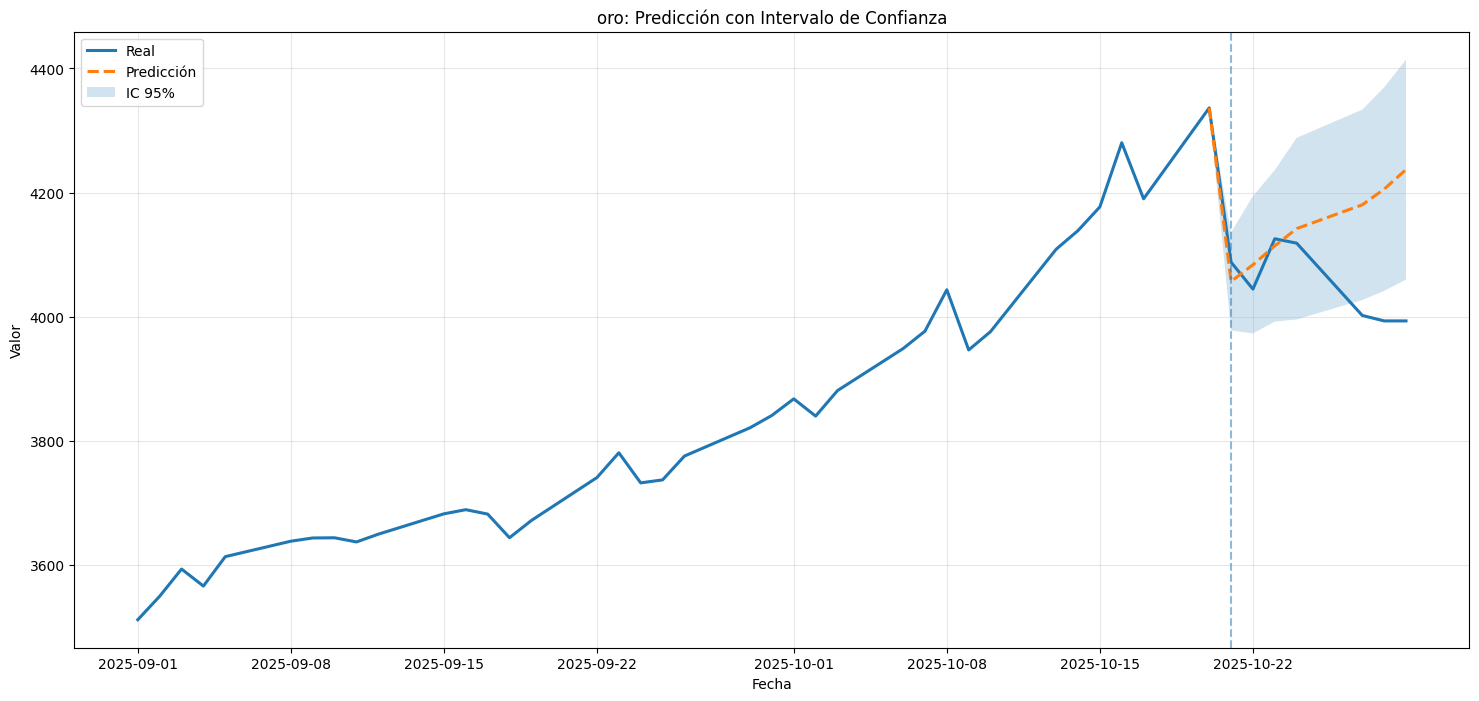

In [24]:
df_plot_oro = evaluate_final_model_with_ci("oro", best_config_oro, df_consol_train, df_consol_test)

plot_prediction_with_ci(
    df_plot_oro,
    "oro",
    df_train=df_consol_train,   
    n_history=36
)

## Plata

In [25]:
grid_plata = [
    {"hidden_size": 128, "lr": 1e-5, "dropout": 0.15, "timesteps": 80, "batch_size": 64, "weight_decay": 1e-4, "bidirectional": False},
    {"hidden_size": 128, "lr": 1e-5, "dropout": 0.15, "timesteps": 100, "batch_size": 64, "weight_decay": 1e-4, "bidirectional": False},
]


df_summary_plata = train_grid_for_asset("plata", grid_plata, df_consol_train)

print("\nRESULTADOS DE LA GRILLA PLATA") 
df_summary_plata


[GRID SEARCH] Iniciando para: plata
Config 0: {'hidden_size': 128, 'lr': 1e-05, 'dropout': 0.15, 'timesteps': 80, 'batch_size': 64, 'weight_decay': 0.0001, 'bidirectional': False}
Config 1: {'hidden_size': 128, 'lr': 1e-05, 'dropout': 0.15, 'timesteps': 100, 'batch_size': 64, 'weight_decay': 0.0001, 'bidirectional': False}

RESULTADOS DE LA GRILLA PLATA


,cfg_id,combined_score,gap_penalty,val_loss,gap,gap_std,rmse_cv_h,val_mape_h,ljung_box_pval_mean,ljung_box_lag_used_mean,train_loss,hidden_size,lr,dropout,timesteps,batch_size,weight_decay,bidirectional,n_exog_used_mean,n_exog_used_std
0,1,7.316522,1.955089,5.361434,4.910177,9.960642,1.255406,5.952599,0.300668,6.0,0.451256,128,0.00001,0.15,100,64,0.0001,False,14.6,1.019804
1,0,7.375263,2.027471,5.347792,5.054942,9.993255,1.002563,4.586057,0.281946,6.0,0.292849,128,0.00001,0.15,80,64,0.0001,False,14.6,1.019804


In [29]:
ID_SELECCIONADO = 1
best_config_plata = df_summary_plata.loc[df_summary_plata['cfg_id'] == ID_SELECCIONADO].iloc[0]

df_predicciones_plata, mape_plata, rmse_plata = evaluate_final_model(
    "plata", 
    best_config_plata, 
    df_consol_train, 
    df_consol_test
)

display(df_predicciones_plata)


[TEST FINAL] Entrenando PLATA | exog_usadas=16

MAPE Promedio: 1.55% | RMSE: 0.9541


,Commodity,y_true,horizon_day,pred_seed_42,pred_seed_33,pred_seed_777,y_pred_mean,Error_Abs,MAPE_Row
FECHA,,,,,,,,,
2025-10-21,plata,47.450001,1,46.852905,47.165936,47.694828,47.237888,0.212112,0.447023
2025-10-22,plata,47.460999,2,47.785992,48.147301,47.372601,47.768631,0.307632,0.648179
2025-10-23,plata,48.481998,3,48.243034,45.500008,46.973122,46.905384,1.576614,3.251958
2025-10-24,plata,48.376999,4,47.633789,46.608795,47.833580,47.358723,1.018276,2.104877
2025-10-27,plata,46.562000,5,48.791096,47.800591,47.809338,48.133678,1.571678,3.375452
2025-10-28,plata,47.509998,6,48.926746,47.195690,47.877308,47.999912,0.489914,1.031181
2025-10-29,plata,47.509998,7,48.256187,47.473866,46.833645,47.521236,0.011238,0.023654


c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(


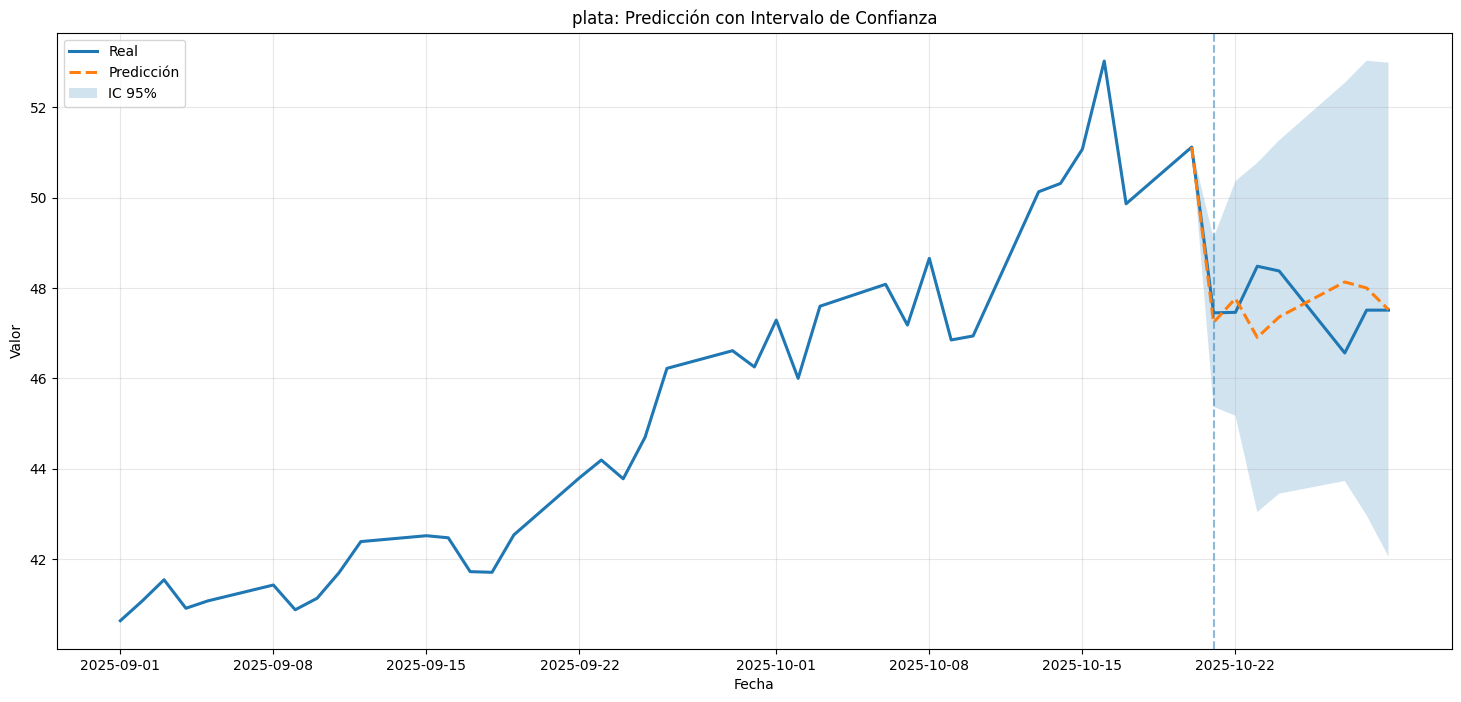

In [30]:
df_plot_plata = evaluate_final_model_with_ci("plata", best_config_plata, df_consol_train, df_consol_test)

plot_prediction_with_ci(
    df_plot_plata,
    "plata",
    df_train=df_consol_train,   
    n_history=36
)

In [31]:
df_pred_plata, df_feat_plata, metrics_plata = evaluate_final_model_complete(
    asset_name="plata",
    best_cfg=best_config_plata,
    df_train=df_consol_train,
    df_test=df_consol_test
)

df_feat_plata

c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(



[TEST FINAL COMPLETO] PLATA | MAPE=1.55% | RMSE=0.9541 | Ljung-Box(lag=6) p=0.8254 | captum_df=df_plata_captum


,feature,importance
0,plata,0.002627
2,ag,0.001717
11,gas_natural,0.001512
4,paas,0.001464
8,pib_ita,0.001400
6,dinero_circulante_reino_unido_m2_aprox_lcu,0.001176
1,cobre,0.000495
13,desempleo_can,0.000488
15,tasa_10y,0.000416
9,eqt,0.000395


## Cobre

grid_cobre = [
    {"hidden_size": 128, "lr": 1e-5, "dropout": 0.15, "timesteps": 120, "batch_size": 64, "weight_decay": 1e-4, "bidirectional": False},
    {"hidden_size": 128, "lr": 1e-5, "dropout": 0.15, "timesteps": 60, "batch_size": 32, "weight_decay": 1e-4, "bidirectional": False},
    {"hidden_size": 128,  "lr": 1e-5, "dropout": 0.15, "timesteps": 96, "batch_size": 64, "weight_decay": 1e-4,  "bidirectional": False},
]

In [37]:
grid_cobre = [
    {"hidden_size": 128, "lr": 1e-3, "dropout": 0.2, "timesteps": 20, "batch_size": 128, "weight_decay": 1e-3, "bidirectional": False},
    {"hidden_size": 96, "lr": 1e-4, "dropout": 0.2, "timesteps": 20, "batch_size": 128, "weight_decay": 1e-3, "bidirectional": False},
    {"hidden_size": 128, "lr": 1e-3, "dropout": 0.2, "timesteps": 10, "batch_size": 128, "weight_decay": 1e-3, "bidirectional": False},
]


df_summary_cobre = train_grid_for_asset("cobre", grid_cobre, df_consol_train)

print("\nRESULTADOS DE LA GRILLA COBRE")
df_summary_cobre


[GRID SEARCH] Iniciando para: cobre
Config 0: {'hidden_size': 128, 'lr': 0.001, 'dropout': 0.2, 'timesteps': 20, 'batch_size': 128, 'weight_decay': 0.001, 'bidirectional': False}
Config 1: {'hidden_size': 96, 'lr': 0.0001, 'dropout': 0.2, 'timesteps': 20, 'batch_size': 128, 'weight_decay': 0.001, 'bidirectional': False}
Config 2: {'hidden_size': 128, 'lr': 0.001, 'dropout': 0.2, 'timesteps': 10, 'batch_size': 128, 'weight_decay': 0.001, 'bidirectional': False}

RESULTADOS DE LA GRILLA COBRE


,cfg_id,combined_score,gap_penalty,val_loss,gap,gap_std,rmse_cv_h,val_mape_h,ljung_box_pval_mean,ljung_box_lag_used_mean,train_loss,hidden_size,lr,dropout,timesteps,batch_size,weight_decay,bidirectional,n_exog_used_mean,n_exog_used_std
0,2,0.751779,0.0,0.751779,0.668153,0.735282,0.091179,3.163208,0.242492,6.0,0.083625,128,0.0010,0.2,10,128,0.001,False,14.4,1.019804
1,0,0.756245,0.0,0.756245,0.674673,0.790025,0.089565,2.968564,0.404535,6.0,0.081573,128,0.0010,0.2,20,128,0.001,False,14.4,1.019804
2,1,0.845467,0.0,0.845467,0.369039,0.562908,0.263962,10.254774,0.302187,6.0,0.476429,96,0.0001,0.2,20,128,0.001,False,14.4,1.019804


In [38]:
ID_SELECCIONADO = 2
best_config_cobre = df_summary_cobre.loc[df_summary_cobre['cfg_id'] == ID_SELECCIONADO].iloc[0]

df_predicciones_cobre, mape_cobre, rmse_cobre = evaluate_final_model(
    "cobre", 
    best_config_cobre, 
    df_consol_train, 
    df_consol_test
)

display(df_predicciones_cobre)


[TEST FINAL] Entrenando COBRE | exog_usadas=15

MAPE Promedio: 1.41% | RMSE: 0.0784


,Commodity,y_true,horizon_day,pred_seed_42,pred_seed_33,pred_seed_777,y_pred_mean,Error_Abs,MAPE_Row
FECHA,,,,,,,,,
2025-10-21,cobre,4.9300,1,4.962101,4.954439,4.979124,4.965221,0.035222,0.714434
2025-10-22,cobre,4.9610,2,4.984581,4.975188,4.994701,4.984823,0.023823,0.480211
2025-10-23,cobre,5.0820,3,5.012426,4.990292,5.018349,5.007022,0.074977,1.475352
2025-10-24,cobre,5.0935,4,5.036955,5.001103,5.049074,5.029044,0.064456,1.265465
2025-10-27,cobre,5.1405,5,5.052592,5.017773,5.072080,5.047482,0.093019,1.809523
2025-10-28,cobre,5.1765,6,5.056598,5.026155,5.106424,5.063059,0.113441,2.191461
2025-10-29,cobre,5.1765,7,5.068310,5.031480,5.130113,5.076634,0.099866,1.929217


c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(


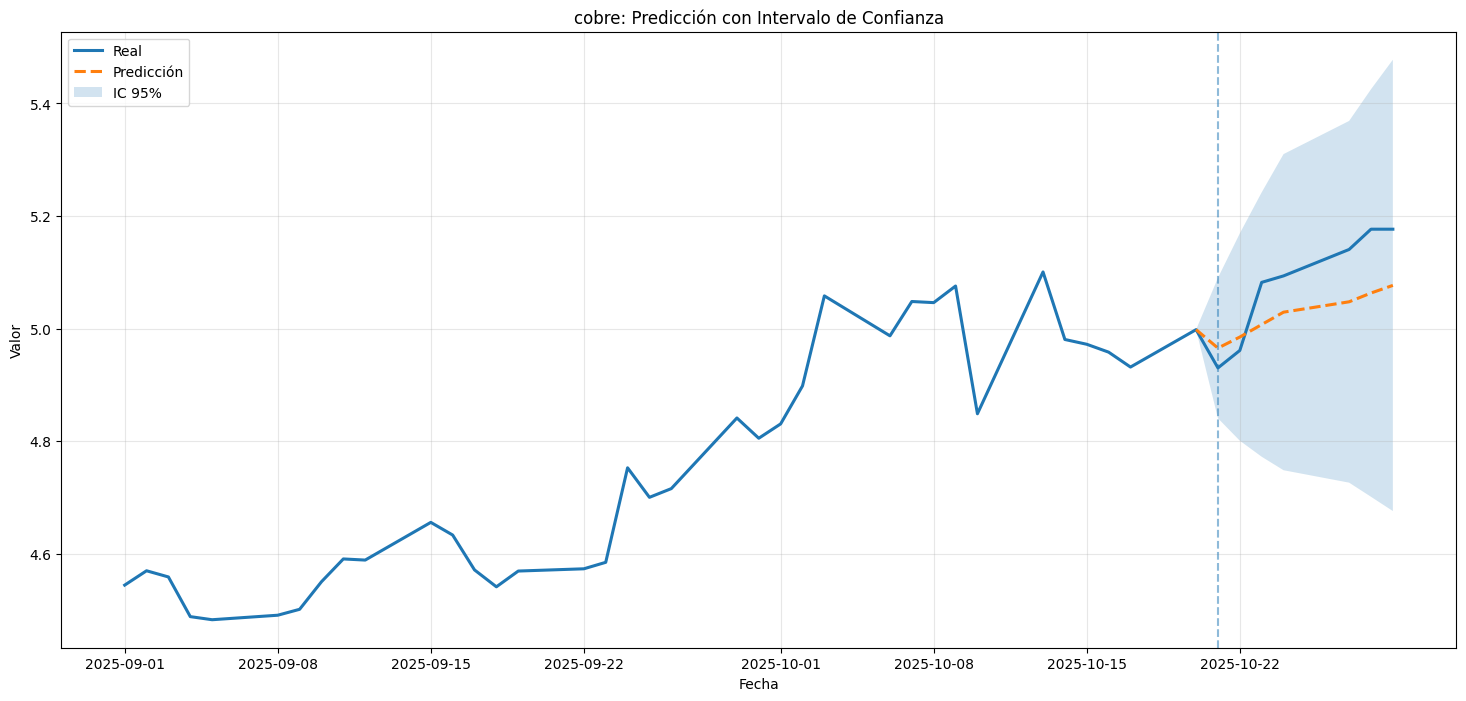

In [40]:
df_plot_cobre = evaluate_final_model_with_ci("cobre", best_config_cobre, df_consol_train, df_consol_test)

plot_prediction_with_ci(
    df_plot_cobre,
    "cobre",
    df_train=df_consol_train,   
    n_history=36
)

In [39]:
df_pred_cobre, df_feat_cobre, metrics_cobre = evaluate_final_model_complete(
    asset_name="cobre",
    best_cfg=best_config_cobre,
    df_train=df_consol_train,
    df_test=df_consol_test
)

df_feat_cobre

c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(



[TEST FINAL COMPLETO] COBRE | MAPE=1.41% | RMSE=0.0784 | Ljung-Box(lag=6) p=0.0528 | captum_df=df_cobre_captum


c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(


,feature,importance
5,dinero_circulante_reino_unido_m2_aprox_lcu,0.037272
13,shanghai,0.018594
0,cobre,0.013992
1,fcx,0.013286
7,ag,0.013209
14,gas_natural,0.012982
9,eqt,0.009919
10,kgc,0.009232
8,tasa_10y,0.008856
15,desempleo_can,0.008416


## Petroleo Brent

In [71]:
grid_petroleo_brent = [ 
    {"hidden_size": 96, "lr": 1e-3, "dropout": 0.2, "timesteps": 30, "batch_size": 32, "weight_decay": 1e-3, "bidirectional": False},
    {"hidden_size": 96, "lr": 1e-4, "dropout": 0.2, "timesteps": 40, "batch_size": 32, "weight_decay": 1e-3, "bidirectional": False},
    {"hidden_size": 128, "lr": 1e-4, "dropout": 0.2, "timesteps": 60, "batch_size": 32, "weight_decay": 1e-3, "bidirectional": False}
]

df_summary_petroleo_brent = train_grid_for_asset("petroleo_brent", grid_petroleo_brent, df_consol_train)

print("\nRESULTADOS DE LA GRILLA PETROLEO BRENT")
df_summary_petroleo_brent


[GRID SEARCH] Iniciando para: petroleo_brent
Config 0: {'hidden_size': 96, 'lr': 0.001, 'dropout': 0.2, 'timesteps': 30, 'batch_size': 32, 'weight_decay': 0.001, 'bidirectional': False}
Config 1: {'hidden_size': 96, 'lr': 0.0001, 'dropout': 0.2, 'timesteps': 40, 'batch_size': 32, 'weight_decay': 0.001, 'bidirectional': False}
Config 2: {'hidden_size': 128, 'lr': 0.0001, 'dropout': 0.2, 'timesteps': 60, 'batch_size': 32, 'weight_decay': 0.001, 'bidirectional': False}

RESULTADOS DE LA GRILLA PETROLEO BRENT


,cfg_id,combined_score,gap_penalty,val_loss,gap,gap_std,rmse_cv_h,val_mape_h,ljung_box_pval_mean,ljung_box_lag_used_mean,train_loss,hidden_size,lr,dropout,timesteps,batch_size,weight_decay,bidirectional,n_exog_used_mean,n_exog_used_std
0,2,0.573831,0.0,0.573831,0.523409,0.635608,3.601886,3.958445,0.144761,6.0,0.050422,128,0.0001,0.2,60,32,0.001,False,14.4,0.8
1,0,0.578109,0.0,0.578109,0.560681,0.744780,3.887294,4.644341,0.104686,6.0,0.017428,96,0.0010,0.2,30,32,0.001,False,14.4,0.8
2,1,0.903046,0.0,0.903046,0.876619,0.694356,3.664210,4.516659,0.209045,6.0,0.026427,96,0.0001,0.2,40,32,0.001,False,14.4,0.8


In [72]:
ID_SELECCIONADO = 2
best_config_petroleo_brent = df_summary_petroleo_brent.loc[df_summary_petroleo_brent['cfg_id'] == ID_SELECCIONADO].iloc[0]

df_predicciones_petroleo_brent, mape_petroleo_brent, rmse_petroleo_brent = evaluate_final_model(
    "petroleo_brent", 
    best_config_petroleo_brent, 
    df_consol_train, 
    df_consol_test
)

display(df_predicciones_petroleo_brent)


[TEST FINAL] Entrenando PETROLEO_BRENT | exog_usadas=14

MAPE Promedio: 3.29% | RMSE: 2.3973


,Commodity,y_true,horizon_day,pred_seed_42,pred_seed_33,pred_seed_777,y_pred_mean,Error_Abs,MAPE_Row
FECHA,,,,,,,,,
2025-10-21,petroleo_brent,61.320000,1,62.422695,63.320610,62.852325,62.865208,1.545208,2.519909
2025-10-22,petroleo_brent,62.590000,2,62.541771,63.165535,62.888008,62.865101,0.275101,0.439528
2025-10-23,petroleo_brent,65.989998,3,62.321819,62.951443,62.646248,62.639835,3.350163,5.076773
2025-10-24,petroleo_brent,65.940002,4,62.403374,62.675728,62.555904,62.545002,3.395000,5.148620
2025-10-27,petroleo_brent,65.620003,5,62.439243,62.654408,62.431042,62.508228,3.111774,4.742113
2025-10-28,petroleo_brent,63.970001,6,62.357929,62.420715,62.343029,62.373890,1.596111,2.495093
2025-10-29,petroleo_brent,63.970001,7,62.493927,62.332863,62.076195,62.300995,1.669006,2.609045


c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(


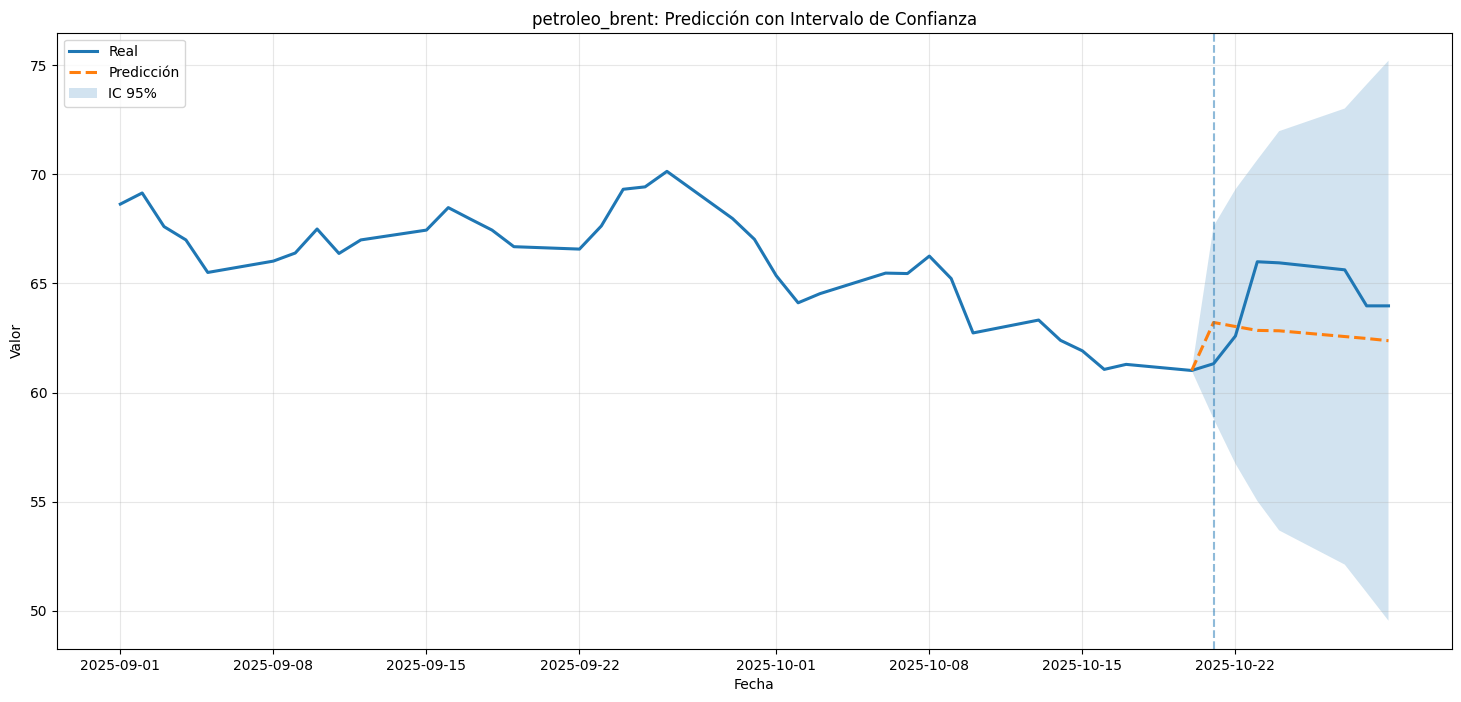

In [43]:
df_plot_petroleo_brent = evaluate_final_model_with_ci("petroleo_brent", best_config_petroleo_brent, df_consol_train, df_consol_test)

plot_prediction_with_ci(
    df_plot_petroleo_brent,
    "petroleo_brent",
    df_train=df_consol_train,   
    n_history=36
)

In [44]:
df_predicciones_petroleo_brent, df_feat_petroleo_brent, metrics_petroleo_brent = evaluate_final_model_complete(
    asset_name="petroleo_brent",
    best_cfg=best_config_petroleo_brent,
    df_train=df_consol_train,
    df_test=df_consol_test
)

df_feat_petroleo_brent

c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(



[TEST FINAL COMPLETO] PETROLEO_BRENT | MAPE=3.25% | RMSE=2.3127 | Ljung-Box(lag=6) p=0.4870 | captum_df=df_petroleo_brent_captum


,feature,importance
6,tasa_10y,0.008456
14,desempleo_fra,0.007959
2,dolar_index,0.006118
7,shanghai,0.006089
0,petroleo_brent,0.005040
3,gas_natural,0.004752
5,pib_ita,0.003932
1,fcx,0.003786
9,desempleo_can,0.003781
4,ag,0.003390


## GAS NATURAL

    {"hidden_size": 128, "lr": 1e-3, "dropout": 0.2, "timesteps": 10, "batch_size": 64, "weight_decay": 5e-5, "bidirectional": False},

In [45]:
grid_gas_natural = [
    {"hidden_size": 96, "lr": 5e-3, "dropout": 0.2, "timesteps": 10, "batch_size": 64, "weight_decay": 5e-5, "bidirectional": False}, 
    {"hidden_size": 96, "lr": 1e-3, "dropout": 0.2, "timesteps": 10, "batch_size": 64, "weight_decay": 1e-4, "bidirectional": False}
    
]
df_summary_gas_natural = train_grid_for_asset("gas_natural", grid_gas_natural, df_consol_train)

print("\nRESULTADOS DE LA GRILLA GAS NATURAL")
df_summary_gas_natural


[GRID SEARCH] Iniciando para: gas_natural
Config 0: {'hidden_size': 96, 'lr': 0.005, 'dropout': 0.2, 'timesteps': 10, 'batch_size': 64, 'weight_decay': 5e-05, 'bidirectional': False}
Config 1: {'hidden_size': 96, 'lr': 0.001, 'dropout': 0.2, 'timesteps': 10, 'batch_size': 64, 'weight_decay': 0.0001, 'bidirectional': False}

RESULTADOS DE LA GRILLA GAS NATURAL


,cfg_id,combined_score,gap_penalty,val_loss,gap,gap_std,rmse_cv_h,val_mape_h,ljung_box_pval_mean,ljung_box_lag_used_mean,train_loss,hidden_size,lr,dropout,timesteps,batch_size,weight_decay,bidirectional,n_exog_used_mean,n_exog_used_std
0,0,0.314586,0.0,0.314586,0.294184,0.182472,0.259659,5.105939,0.233215,6.0,0.020402,96,0.005,0.2,10,64,0.00005,False,13.8,1.16619
1,1,0.508588,0.0,0.508588,0.443097,0.501702,0.392210,9.500522,0.167190,6.0,0.065492,96,0.001,0.2,10,64,0.00010,False,13.8,1.16619


In [46]:
ID_SELECCIONADO = 0
best_config_gas_natural = df_summary_gas_natural.loc[df_summary_gas_natural['cfg_id'] == ID_SELECCIONADO].iloc[0]

df_predicciones_gas_natural, mape_gas_natural, rmse_gas_natural = evaluate_final_model(
    "gas_natural", 
    best_config_gas_natural, 
    df_consol_train, 
    df_consol_test
)

display(df_predicciones_gas_natural)


[TEST FINAL] Entrenando GAS_NATURAL | exog_usadas=15

MAPE Promedio: 1.31% | RMSE: 0.0681


,Commodity,y_true,horizon_day,pred_seed_42,pred_seed_33,pred_seed_777,y_pred_mean,Error_Abs,MAPE_Row
FECHA,,,,,,,,,
2025-10-21,gas_natural,3.474,1,3.250866,3.461410,3.548730,3.420335,0.053665,1.544759
2025-10-22,gas_natural,3.450,2,3.251689,3.425427,3.512979,3.396699,0.053301,1.544966
2025-10-23,gas_natural,3.344,3,3.229175,3.376452,3.461676,3.355767,0.011767,0.351896
2025-10-24,gas_natural,3.304,4,3.210621,3.331375,3.417868,3.319955,0.015955,0.482891
2025-10-27,gas_natural,3.442,5,3.182378,3.291424,3.366989,3.280264,0.161736,4.698903
2025-10-28,gas_natural,3.237,6,3.178626,3.236421,3.321139,3.245395,0.008395,0.259358
2025-10-29,gas_natural,3.237,7,3.155430,3.227316,3.301215,3.227987,0.009013,0.278450


c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(


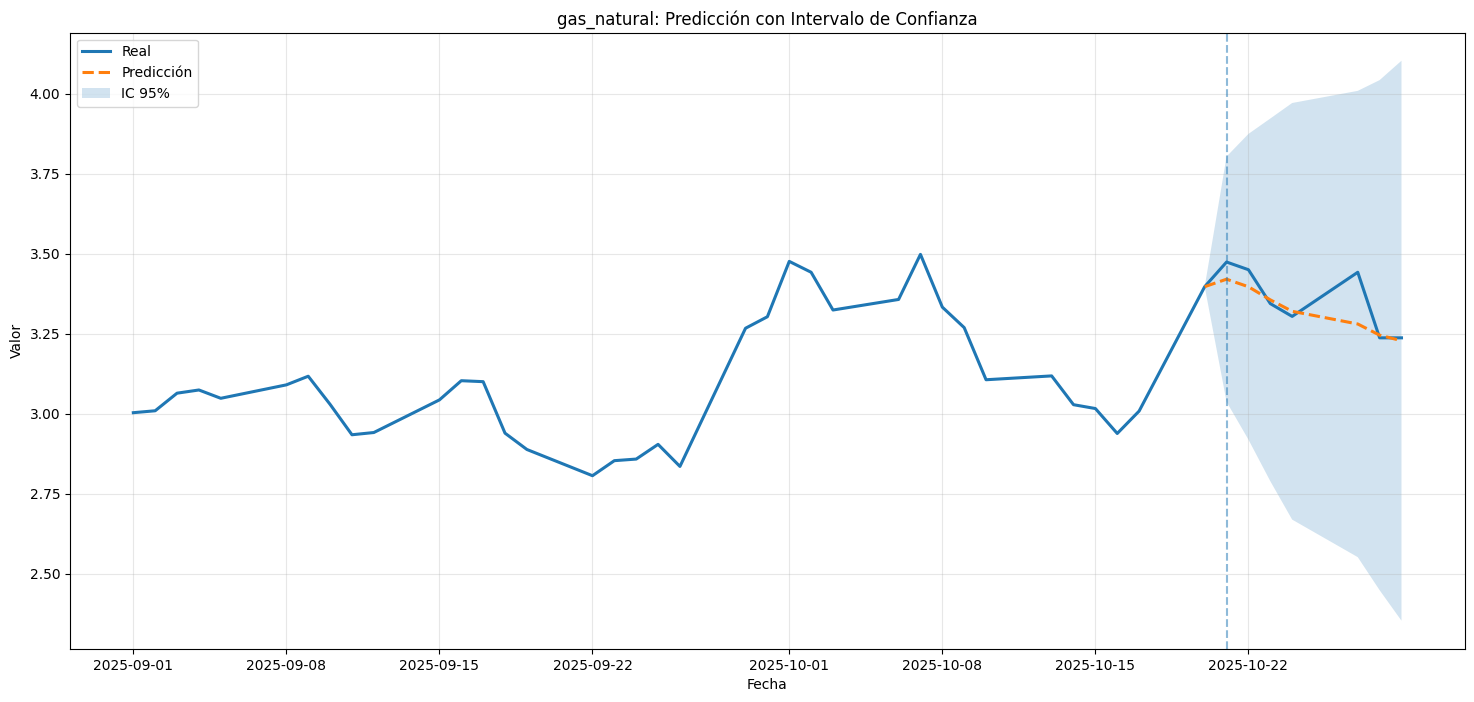

In [47]:
df_plot_gas_natural = evaluate_final_model_with_ci("gas_natural", best_config_gas_natural, df_consol_train, df_consol_test)

plot_prediction_with_ci(
    df_plot_gas_natural,
    "gas_natural",
    df_train=df_consol_train,   
    n_history=36
)

In [48]:
df_predicciones_gas_natural, df_feat_gas_natural, metrics_gas_natural = evaluate_final_model_complete(
    asset_name="gas_natural",
    best_cfg=best_config_gas_natural,
    df_train=df_consol_train,
    df_test=df_consol_test
)

df_feat_gas_natural

c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(



[TEST FINAL COMPLETO] GAS_NATURAL | MAPE=1.31% | RMSE=0.0681 | Ljung-Box(lag=6) p=0.6580 | captum_df=df_gas_natural_captum


c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(


,feature,importance
0,gas_natural,0.095435
13,shanghai,0.069269
2,tasa_10y,0.031398
6,dinero_circulante_reino_unido_m2_aprox_lcu,0.029623
4,fcx,0.015264
8,paas,0.015165
11,ag,0.011368
10,desempleo_can,0.008077
7,vix,0.007439
5,desempleo_fra,0.007235
